<a href="https://colab.research.google.com/github/sonalsingh1806/sentimentAnalysis/blob/AqsaDev/senti_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Review  400000 non-null  object
 1   Label   400000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.1+ MB
None
                                              Review  Label
0  Great CD: My lovely Pat has one of the GREAT v...      1
1  One of the best game music soundtracks - for a...      1
2  Batteries died within a year ...: I bought thi...      0
3  works fine, but Maha Energy is better: Check o...      1
4  Great for the non-audiophile: Reviewed quite a...      1


<ipython-input-6-bdd531ecf95e>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=data, palette='coolwarm')


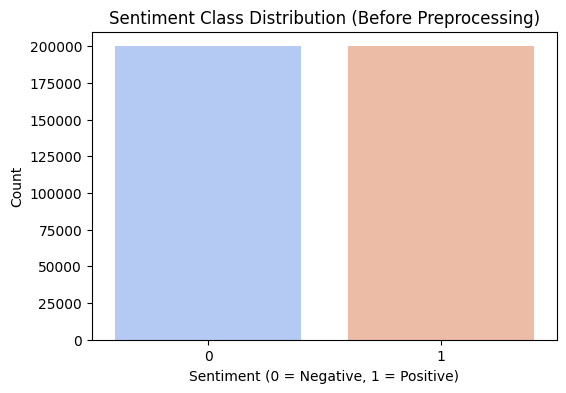

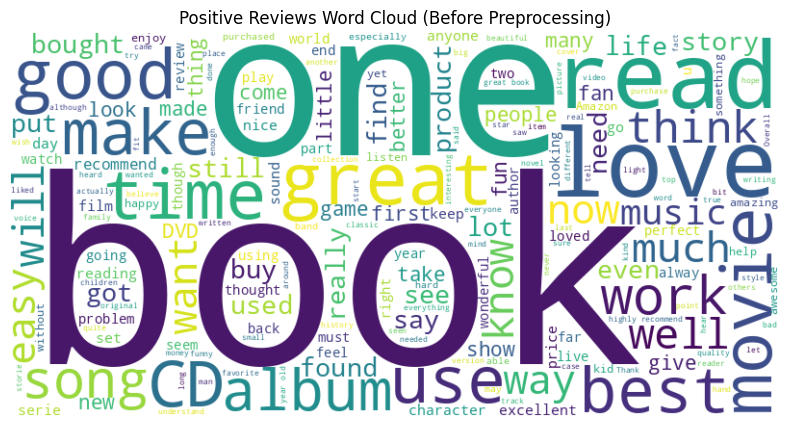

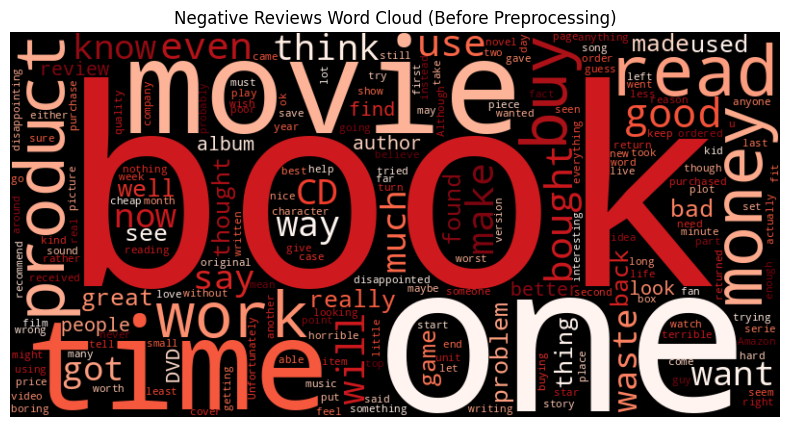

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
<ipython-input-6-bdd531ecf95e>:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=data, palette='coolwarm')


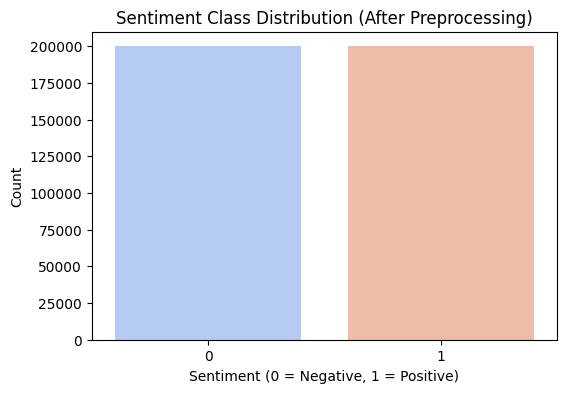

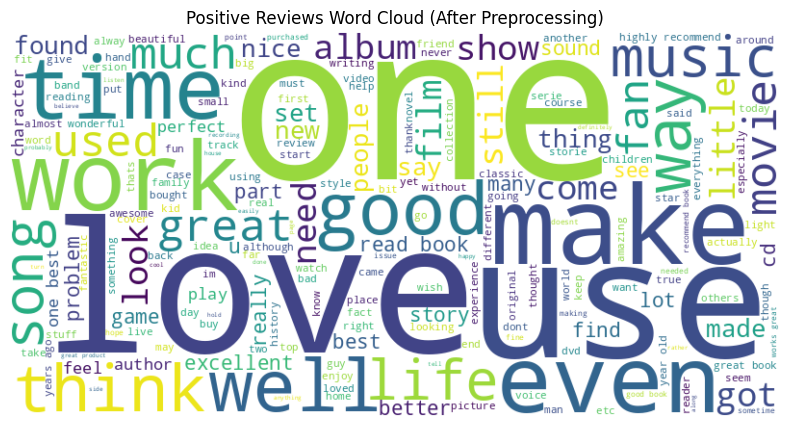

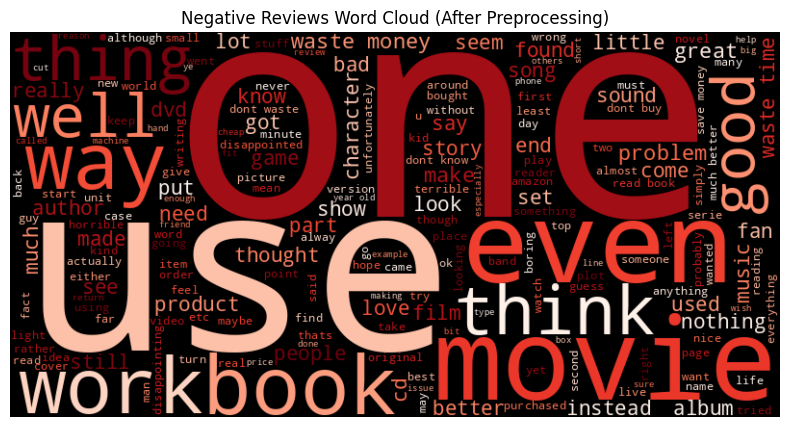

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import Word2Vec
import numpy as np

# Load data
data = pd.read_csv("/content/amazon_reviews 2.csv")

# Display basic info
print(data.info())
print(data.head())

# Check class distribution before preprocessing
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=data, palette='coolwarm')
plt.title("Sentiment Class Distribution (Before Preprocessing)")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

# Generate word clouds for positive and negative reviews before preprocessing
positive_reviews = " ".join(data[data['Label'] == 1]['Review'])
negative_reviews = " ".join(data[data['Label'] == 0]['Review'])

# Positive reviews word cloud (before)
plt.figure(figsize=(10, 5))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews Word Cloud (Before Preprocessing)")
plt.show()

# Negative reviews word cloud (before)
plt.figure(figsize=(10, 5))
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews Word Cloud (Before Preprocessing)")
plt.show()

# Check for missing values and drop rows with missing values
data.dropna(subset=['Review', 'Label'], inplace=True)
data.drop_duplicates(subset='Review', inplace=True)

# Text Cleaning
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

data['Cleaned_Review'] = data['Review'].apply(clean_text)

# Remove stop words
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])

data['Cleaned_Review'] = data['Cleaned_Review'].apply(remove_stopwords)

# Tokenizing
nltk.download("punkt")
data['Tokenized_Review'] = data['Cleaned_Review'].apply(word_tokenize)

# Check class distribution after preprocessing
plt.figure(figsize=(6, 4))
sns.countplot(x='Label', data=data, palette='coolwarm')
plt.title("Sentiment Class Distribution (After Preprocessing)")
plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()

# Generate word clouds for positive and negative reviews after preprocessing
positive_reviews_cleaned = " ".join(data[data['Label'] == 1]['Cleaned_Review'])
negative_reviews_cleaned = " ".join(data[data['Label'] == 0]['Cleaned_Review'])

# Positive reviews word cloud (after)
plt.figure(figsize=(10, 5))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews_cleaned)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Reviews Word Cloud (After Preprocessing)")
plt.show()

# Negative reviews word cloud (after)
plt.figure(figsize=(10, 5))
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews_cleaned)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Negative Reviews Word Cloud (After Preprocessing)")
plt.show()
